# Statistics for WLASL: Pre-processed

In [24]:
import json
from pathlib import Path
from typing import cast, List, TypedDict, Dict, Tuple
import matplotlib.pyplot as plt
import numpy as np
#locals
from configs import WLASL_ROOT, SPLIT_DIR, CLASSES_PATH
from video_dataset import get_wlasl_info
import stats
import preprocess as preproc
from statistics import median, mean, median_high, median_low
import pandas as pd      # not imported previously, so do it here
from IPython.display import display



# TODO:
- make a flag to control preprocessed vs unprocessed
- add removed instances
- add bounding box info

## Split

#### Pick split

In [25]:
split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
print('Options:')
for i, split_name in enumerate(split_options):
    print(f'{i} : {split_name}')

Options:
0 : asl100
1 : asl300
2 : asl1000
3 : asl2000


doing this for SAICIST because those experiments kept bad frame range labeled images

In [26]:
# labels_dir = Path('./preprocessed/labels_new')
labels_dir = Path('./preprocessed/labels_old_nobbox') 

with open(CLASSES_PATH, 'r') as f:
    classes = json.load(f)

## Preprocessed

Removed due to limited number of frames (cutoff 9):

Split :  Videos
asl1000 : 18223, 59958
asl2000 : 18223, 59958, 15144

if frame start or frame end were labeled wrong, they were set to 0 or frame length

In [27]:
def get_min_max_num_instances(per_instance_stats: Dict[str, stats.instance_stats]) -> Tuple[int, int]:
    """Returns the minumum and maximum number of instances in a dictionary of instance stats

    Args:
        per_instance_stats (Dict[str, stats.instance_stats]): A dictionary with stats for each class indexed by label_name

    Returns:
        Tuple[int, int]: min, max number of instances.
    """
    mini = float('inf')
    maxi = float(0)
    for inst_stats in per_instance_stats.values():
        num_inst = inst_stats['num_instances']
        if num_inst > maxi:
            maxi = num_inst
        if num_inst < mini:
            mini = num_inst
    return int(mini), int(maxi) 



In [28]:
def get_min_max_num_signers(per_instance_stats: Dict[str, stats.instance_stats]) -> Tuple[int, int]:
    """Returns the minumum and maximum number of signers in a dictionary of instance stats

    Args:
        per_instance_stats (Dict[str, stats.instance_stats]): A dictionary with stats for each class indexed by label_name

    Returns:
        Tuple[int, int]: min, max number of signers.
    """
    mini = float('inf')
    maxi = float(0)
    for inst_stats in per_instance_stats.values():
        num_signers = len(inst_stats['signers_distribution'])
        if num_signers > maxi:
            maxi = num_signers
        if num_signers < mini:
            mini = num_signers
    return int(mini), int(maxi) 

In [29]:
def create_instances_table(per_set_stats: Dict[stats.AVAIL_SETS, stats.set_stats]) -> pd.DataFrame:
    rows = []
    for set_name, set_stats in per_set_stats.items():
        mini_i, maxi_i = get_min_max_num_instances(set_stats['per_instance_stats'])
        mini_s, maxi_s = get_min_max_num_signers(set_stats['per_instance_stats'])
        rows.append({
            'Set name': set_name,
            'Num instances': set_stats['num_instances'],
            'Num signers': set_stats['num_signers'],
            'instances per gloss': f'[{mini_i} - {maxi_i}]',
            'signers per gloss': f'[{mini_s} - {maxi_s}]'
        })

    return pd.DataFrame(rows)
    

In [30]:
all_splits = {split : {} for split in split_options}

for split_name in split_options:
    split_dir = labels_dir / split_name
    set_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern='*_instances*.json')
    seperated = {}
    set_keys = ['train', 'test', 'val']
    print(f'Split info for {split_name}')
    for  key, value in set_info.items():
        preproc_set = cast(List[preproc.InstanceDict], value)
        for set_key in set_keys:
            if key.startswith(set_key):
                seperated[set_key] = preproc_set
                break
    
    sep_wlasl_order = {}
    for key, value in seperated.items():
        sep_wlasl_order[key] = stats.reverse_preproc_format(value, classes=classes)

    
    per_set_stats = {}
    for set_name, glosses_subset in sep_wlasl_order.items():
        per_set_stats[set_name] = stats.get_set_stats(glosses_subset)

    all_splits[split_name] = per_set_stats
    
    display(create_instances_table(per_set_stats))
    print('\n', '-'*10)

Split info for asl100


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,338,69,[3 - 6],[2 - 6]
1,train,1442,91,[12 - 30],[7 - 15]
2,test,258,56,[2 - 5],[2 - 4]



 ----------
Split info for asl300


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,901,88,[2 - 6],[2 - 6]
1,train,3549,104,[9 - 30],[5 - 15]
2,test,668,74,[2 - 5],[1 - 4]



 ----------
Split info for asl1000


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,2319,101,[1 - 6],[1 - 6]
1,train,8977,113,[6 - 30],[4 - 15]
2,test,1876,89,[1 - 5],[1 - 4]



 ----------
Split info for asl2000


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,3917,109,[1 - 6],[1 - 6]
1,train,14290,117,[1 - 30],[1 - 15]
2,test,2879,105,[1 - 5],[1 - 4]



 ----------


In [31]:

def get_numinstances_distribution(set_statistics: stats.set_stats):
    return stats.HistoGram(
        {gloss : instance['num_instances'] for gloss, instance in set_statistics['per_instance_stats'].items()}
    )
    

In [32]:
split_name: stats.AVAIL_SPLITS = 'asl2000'
num_classes = split_name[3:]
set_name: stats.AVAIL_SETS = 'test'
per_set_stats = all_splits[split_name]

In [33]:
num_classes = int(split_name[3:])
print(num_classes)

2000


/home/luke/Code/SLR/code/stats.py:471: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


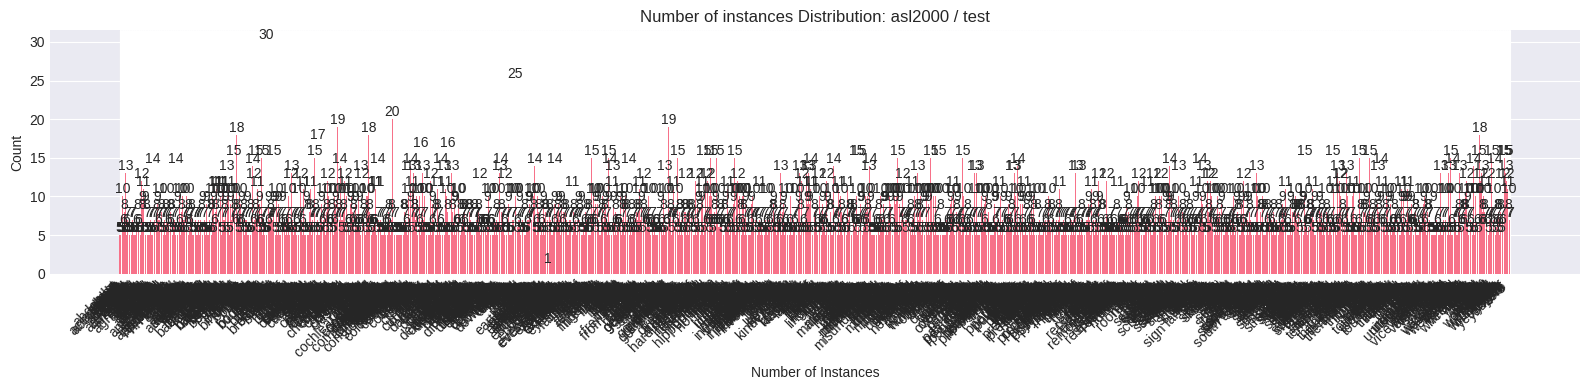

In [34]:
num_inst_dist = get_numinstances_distribution(per_set_stats['train']) #want the training distribution

stats.plot_distribution(num_inst_dist, set_name=set_name, split_name=split_name, metric='Number of Instances', categorical=True, figsize=(16, 4))

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from typing import Dict, Optional, Union, Any

def plot_instances_vs_f1(
    instance_counts: Dict[str, int],
    cls_report: Dict[str, Dict[str, float]],
    class_to_idx: Dict[str, int],
    save_path: Optional[Union[str, Path]] = None,
) -> None:
    """Plot correlation between number of training instances per gloss and per-class F1 score.

    Args:
        instance_counts: Dict mapping gloss name -> instance count.
        cls_report: Classification report dict from sklearn (output of test_topk_clsrep).
        class_to_idx: Dict mapping gloss name -> numeric class index.
        save_path: Optionally save the figure. Defaults to None.
    """
    counts = []
    f1_scores = []
    labels = []

    for gloss, count in instance_counts.items():
        idx = class_to_idx.get(gloss)
        if idx is None:
            continue
        report_entry = cls_report.get(str(idx))
        if report_entry is None:
            continue
        counts.append(count)
        f1_scores.append(report_entry["f1-score"])
        labels.append(gloss)

    counts = np.array(counts)
    f1_scores = np.array(f1_scores)

    # Pearson correlation + regression line
    # r, p = stats.pearsonr(counts, f1_scores)
    
    # With Kendall:
    tau, p = stats.kendalltau(counts, f1_scores)
    
    slope, intercept, *_ = stats.linregress(counts, f1_scores)
    x_line = np.linspace(counts.min(), counts.max(), 200)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(counts, f1_scores, alpha=0.6, edgecolors="white", linewidths=0.4,
               s=60, color="#4C72B0", zorder=3)
    # ax.plot(x_line, y_line, color="#DD4444", linewidth=1.5,
    #         label=f"Linear fit  (r = {r:.3f}, p = {p:.3e})")
    ax.plot(x_line, y_line, color="#DD4444", linewidth=1.5,
            label=f"Linear fit (Kendall $\\tau$ = {tau:.3f}, p = {p:.3e})")
    ax.set_xlabel("Number of instances", fontsize=12)
    ax.set_ylabel("F1 score", fontsize=12)
    ax.set_title("Per-gloss instance count vs. recognition F1 score", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()

In [36]:
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

In [37]:
exps_dict_path = Path('./results/wlasl_saicist.json')
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)



for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)

In [38]:
# model_name = 'MViTv2_S'
model_name = 'S3D'

In [39]:
print(exps_dict[split_name][model_name])

['000']


In [40]:
import torch
runs_dir = Path('./runs') / split_name
checkpoint_path = runs_dir / f'{model_name}_exp{exps_dict[split_name][model_name][0]}' / 'checkpoints' / 'best.pth'
checkpoint = torch.load(checkpoint_path)

/tmp/ipykernel_3206847/542821056.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


In [41]:
print(checkpoint.keys())

odict_keys(['backbone.0.0.0.0.weight', 'backbone.0.0.0.1.weight', 'backbone.0.0.0.1.bias', 'backbone.0.0.0.1.running_mean', 'backbone.0.0.0.1.running_var', 'backbone.0.0.0.1.num_batches_tracked', 'backbone.0.0.1.0.weight', 'backbone.0.0.1.1.weight', 'backbone.0.0.1.1.bias', 'backbone.0.0.1.1.running_mean', 'backbone.0.0.1.1.running_var', 'backbone.0.0.1.1.num_batches_tracked', 'backbone.0.2.0.weight', 'backbone.0.2.1.weight', 'backbone.0.2.1.bias', 'backbone.0.2.1.running_mean', 'backbone.0.2.1.running_var', 'backbone.0.2.1.num_batches_tracked', 'backbone.0.3.0.0.weight', 'backbone.0.3.0.1.weight', 'backbone.0.3.0.1.bias', 'backbone.0.3.0.1.running_mean', 'backbone.0.3.0.1.running_var', 'backbone.0.3.0.1.num_batches_tracked', 'backbone.0.3.1.0.weight', 'backbone.0.3.1.1.weight', 'backbone.0.3.1.1.bias', 'backbone.0.3.1.1.running_mean', 'backbone.0.3.1.1.running_var', 'backbone.0.3.1.1.num_batches_tracked', 'backbone.0.5.branch0.0.weight', 'backbone.0.5.branch0.1.weight', 'backbone.0.5.

In [42]:
from models import get_model

MViT = get_model(model_name, num_classes, 0.5)


In [43]:
MViT.load_state_dict(checkpoint)

<All keys matched successfully>

In [44]:
from models import norm_vals
from testing import setup_data
dloader, num_classes, m_permt, m_sh_et = setup_data(
		set_name='test',
		norm_dict=norm_vals(model_name),
		split=split_name,
		frame_size=224,
		num_frames=16,
		shuffle=False,
	)

In [45]:
from testing import test_topk_clsrep

topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
		model=MViT,
		test_loader=dloader,
		verbose=False,
	)

Testing:   0%|          | 8/2879 [00:00<01:04, 44.31it/s]

Testing: 100%|██████████| 2879/2879 [00:37<00:00, 76.25it/s]

top-k average per class acc: 0.17618333333333333, 0.44055, 0.5528833333333333
top-k per instance acc: 0.19624869746439735, 0.4696075026050712, 0.582493921500521
Averag Loss: 4.43


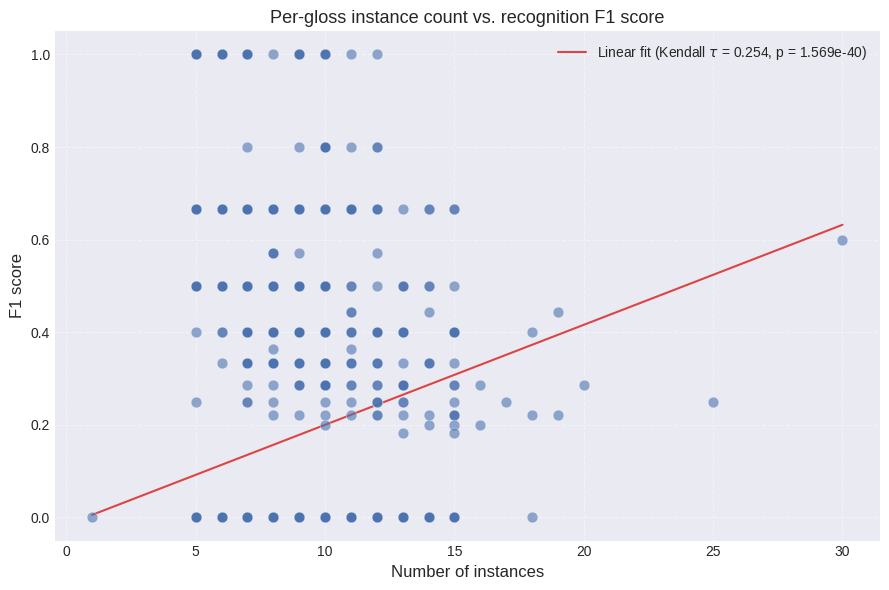

In [46]:
from configs import CLASSES_PATH
import json

with open(CLASSES_PATH, 'r') as f:
    classes = json.load(f)
    
clss_to_idx = {gloss: idx for idx, gloss in enumerate(classes)}

plot_instances_vs_f1(num_inst_dist, cls_report, clss_to_idx, save_path=f'results/corr_mat_{model_name}.pdf')

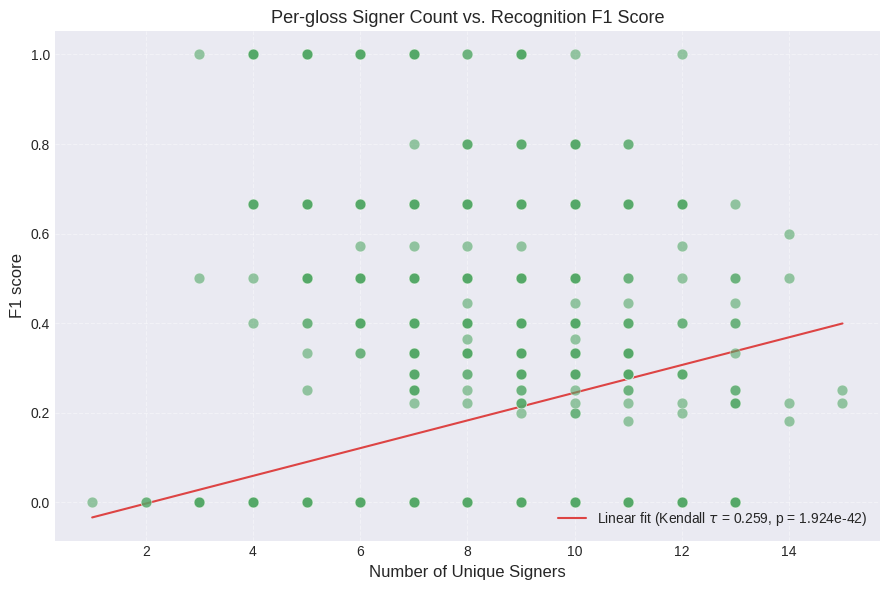

Kendall's tau: 0.2587
p-value: 1.9241e-42


In [50]:

from scipy import stats
from typing import Dict, Optional, Union, Any

def plot_signers_vs_f1(
    set_statistics: dict,
    cls_report: Dict[str, Dict[str, float]],
    class_to_idx: Dict[str, int],
    save_path: Optional[Union[str, Any]] = None,
) -> None:
    """Plot correlation between number of unique training signers per gloss and per-class F1 score."""
    
    # 1. Extract the number of unique signers per gloss
    # set_statistics['per_instance_stats'] contains 'signers_distribution' list
    signer_counts = {
        gloss: len(instance['signers_distribution']) 
        for gloss, instance in set_statistics['per_instance_stats'].items()
    }
    
    counts = []
    f1_scores = []
    labels = []

    # 2. Match counts with F1 scores using class_to_idx
    for gloss, count in signer_counts.items():
        idx = class_to_idx.get(gloss)
        if idx is None:
            continue
        report_entry = cls_report.get(str(idx))
        if report_entry is None:
            continue
        counts.append(count)
        f1_scores.append(report_entry["f1-score"])
        labels.append(gloss)

    counts = np.array(counts)
    f1_scores = np.array(f1_scores)

    # 3. Calculate Kendall's Tau and Linear Regression
    tau, p_val = stats.kendalltau(counts, f1_scores)
    slope, intercept, *_ = stats.linregress(counts, f1_scores)
    x_line = np.linspace(counts.min(), counts.max(), 200)
    y_line = slope * x_line + intercept

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(counts, f1_scores, alpha=0.6, edgecolors="white", linewidths=0.4,
               s=60, color="#55A868", zorder=3) # Green color for signers
    ax.plot(x_line, y_line, color="#DD4444", linewidth=1.5,
            label=f"Linear fit (Kendall $\\tau$ = {tau:.3f}, p = {p_val:.3e})")

    ax.set_xlabel("Number of Unique Signers", fontsize=12)
    ax.set_ylabel("F1 score", fontsize=12)
    ax.set_title("Per-gloss Signer Count vs. Recognition F1 Score", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()
    
    print(f"Kendall's tau: {tau:.4f}")
    print(f"p-value: {p_val:.4e}")

# --- How to call the function ---
# Pass the 'train' split stats directly, along with your existing variables
plot_signers_vs_f1(
    set_statistics=per_set_stats['train'], 
    cls_report=cls_report, 
    class_to_idx=clss_to_idx, 
    save_path=f'results/corr_signers_{model_name}.pdf'
)